Using cuda
Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.01MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.39MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Extracting CT features...
Training Model...
Epoch 001 | Loss: 2.3210 | Accuracy: 22.42%
Epoch 002 | Loss: 2.2109 | Accuracy: 32.67%
Epoch 003 | Loss: 2.1145 | Accuracy: 34.61%
Epoch 004 | Loss: 2.0232 | Accuracy: 34.51%
Epoch 005 | Loss: 1.9360 | Accuracy: 34.03%
Epoch 006 | Loss: 1.8576 | Accuracy: 34.61%
Epoch 007 | Loss: 1.7822 | Accuracy: 35.71%
Epoch 008 | Loss: 1.7061 | Accuracy: 37.88%
Epoch 009 | Loss: 1.6267 | Accuracy: 41.33%
Epoch 010 | Loss: 1.5442 | Accuracy: 45.45%
Epoch 011 | Loss: 1.4656 | Accuracy: 49.82%
Epoch 012 | Loss: 1.3913 | Accuracy: 53.52%
Epoch 013 | Loss: 1.3197 | Accuracy: 56.48%
Epoch 014 | Loss: 1.2501 | Accuracy: 58.42%
Epoch 015 | Loss: 1.1854 | Accuracy: 59.81%
Epoch 016 | Loss: 1.1240 | Accuracy: 61.27%
Epoch 017 | Loss: 1.0697 | Accuracy: 62.90%
Epoch 018 | Loss: 1.0150 | Accuracy: 64.61%
Epoch 019 | Loss: 0.9663 | Accuracy: 66.38%
Epoch 020 | Loss: 0.9225 | Accuracy: 67.96%
E

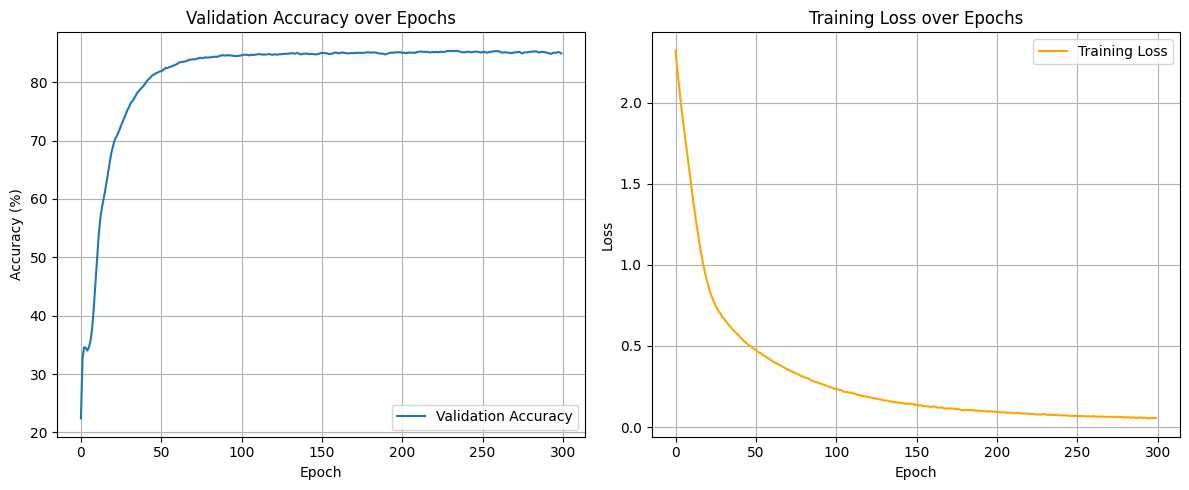

In [ ]:
# ==================== IMPORTS ====================
import torch, torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using", device)

# ==================== LOAD DATA ====================
transform = transforms.ToTensor()
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=60000, shuffle=True)
testloader = DataLoader(testset, batch_size=10000, shuffle=False)

X_train, y_train = next(iter(trainloader))
X_test, y_test = next(iter(testloader))

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# ==================== CT FEATURE EXTRACTOR ====================
def ct_features(images, patch_size=3, stride=1, num_bins=4):
    B, C, H, W = images.shape
    unfolded = F.unfold(images, kernel_size=patch_size, stride=stride)
    unfolded = unfolded.transpose(1, 2)
    quantized = torch.floor(unfolded * num_bins)
    quantized = torch.clamp(quantized, 0, num_bins - 1)
    weights = torch.arange(1, patch_size * patch_size + 1, device=device).float()
    hashes = torch.matmul(quantized, weights)
    hist_feats = []
    for i in range(B):
        hist = torch.histc(hashes[i], bins=256, min=0, max=255)
        hist_feats.append(hist)
    return torch.stack(hist_feats).to(device)

# ==================== MULTI-SCALE FEATURES ====================
def multi_ct_features(images):
    feats = []
    for patch in [2, 3, 5]:
        feats.append(ct_features(images, patch_size=patch))
    return torch.cat(feats, dim=1)

print("Extracting CT features...")
X_train_feat = multi_ct_features(X_train)
X_test_feat = multi_ct_features(X_test)

# ==================== NORMALIZATION ====================
scaler = StandardScaler()
X_train_feat_np = scaler.fit_transform(X_train_feat.cpu().numpy())
X_test_feat_np = scaler.transform(X_test_feat.cpu().numpy())

X_train_feat = torch.tensor(X_train_feat_np, dtype=torch.float32).to(device)
X_test_feat = torch.tensor(X_test_feat_np, dtype=torch.float32).to(device)

# ==================== DEEP MLP ====================
class CTClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.model(x)

model = CTClassifier(X_train_feat.shape[1]).to(device)

# ==================== TRAIN ====================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Training Model...")
epochs = 300
train_loss_list = []
val_acc_list = []

for epoch in range(epochs):
    model.train()
    outputs = model(X_train_feat)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss_list.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_feat)
        acc = (test_pred.argmax(1) == y_test).float().mean().item()
        val_acc_list.append(acc * 100)

    print(f"Epoch {epoch+1:03} | Loss: {loss.item():.4f} | Accuracy: {acc * 100:.2f}%")

# ==================== PLOT ====================
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(val_acc_list, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy over Epochs")
plt.grid(True)
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss_list, color='orange', label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
